# Data Engineering & EDA Workshop
**Objective:** Connect to a Neon PostgreSQL cloud database, generate and insert synthetic data, perform data cleaning and transformation with Pandas, and construct standard and advanced visualizations.

## 1. Data Collection
We created a cloud-hosted PostgreSQL database using Neon.tech. 
To populate the `employees` table, we generate 60 realistic synthetic records using Python's `Faker` library, specifying:
- Realistic IT job titles (Data Analyst, Software Engineer, Cloud Architect, etc.)
- Start dates between January 1, 2015, and December 31, 2024
- Annual salaries ranging from $60,000 to $200,000

We then connect to Neon using `psycopg2` to insert the records and query them back into a Pandas DataFrame.

In [5]:
import os
import psycopg2
from dotenv import load_dotenv
from faker import Faker
import random
from datetime import date

# 1. Load the Neon database connection string from .env
load_dotenv(override=True)
CONNECTION_URI = os.getenv("DATABASE_URL")
if CONNECTION_URI:
    CONNECTION_URI = CONNECTION_URI.strip().strip('"').strip("'")
if not CONNECTION_URI:
    raise RuntimeError("DATABASE_URL is missing from the .env file")

# 2. Generate 60 synthetic employees using Faker
fake = Faker()
random.seed(42)  # For reproducible results

positions = [
    'Data Analyst', 
    'Software Engineer', 
    'DevOps Engineer', 
    'Cloud Architect', 
    'Cybersecurity Specialist'
 ]

employee_records = []
for emp_id in range(1, 61):
    name = fake.name()
    position = random.choice(positions)
    start_date = fake.date_between_dates(date_start=date(2015, 1, 1), date_end=date(2024, 12, 31))
    salary = random.randint(60000, 200000)
    employee_records.append((emp_id, name, position, start_date, salary))

# 3. Connect to Neon and Insert Records
conn = psycopg2.connect(CONNECTION_URI)
cursor = conn.cursor()

# Ensure table exists (in case it needs recreation)
cursor.execute("""
CREATE TABLE IF NOT EXISTS employees (
    employee_id INT PRIMARY KEY,
    name VARCHAR(100),
    position VARCHAR(100),
    start_date DATE,
    salary INT
 );
""")

# Insert records into the table
insert_query = """
INSERT INTO employees (employee_id, name, position, start_date, salary)
VALUES (%s, %s, %s, %s, %s)
ON CONFLICT (employee_id) DO NOTHING;
"""
cursor.executemany(insert_query, employee_records)
conn.commit()

print(f"Successfully inserted {len(employee_records)} employee records into Neon PostgreSQL!")
cursor.close()
conn.close()

Successfully inserted 60 employee records into Neon PostgreSQL!


Loading the data into a Pandas DataFrame


In [2]:
import pandas as pd
from sqlalchemy import create_engine

# 1. Create an engine using your Neon URI
# SQLAlchemy expects 'postgresql+psycopg2://' or 'postgresql://'
engine = create_engine(CONNECTION_URI)

# 2. Query directly through the engine
sql_query = "SELECT * FROM employees ORDER BY employee_id ASC;"
df = pd.read_sql_query(sql_query, con=engine)

# 3. Display the first few rows
print("First 5 rows loaded from Cloud SQL:")
df.head()

First 5 rows loaded from Cloud SQL:


,employee_id,name,position,start_date,salary
0,1,Michael Alexander,Data Analyst,2024-06-27,66556
1,2,Pamela Chan,DevOps Engineer,2024-11-14,124196
2,3,Eileen Mcclure,Software Engineer,2019-08-01,96579
3,4,Christopher Warner,Data Analyst,2019-05-07,82790
4,5,William Parker,Cybersecurity Specialist,2022-09-22,170604


## 2. Data Cleaning
Before running exploratory data analysis, we audit the dataset for structural integrity:
1. **Missing Values (`isnull().sum()`):** Check for missing entries across all columns.
2. **Data Types (`info()`):** Ensure `start_date` is properly converted to a DateTime object and `salary` is numeric.
3. **Descriptive Statistics (`describe()`):** Verify numerical ranges fall within expected domain parameters ($60,000–$200,000).

In [3]:
# 1. Structural information
print("=== DATASET INFO ===")
df.info()

# 2. Check for missing / null values
print("\n=== MISSING VALUES PER COLUMN ===")
print(df.isnull().sum())

# 3. Convert start_date to datetime format if not already done
df['start_date'] = pd.to_datetime(df['start_date'])

# 4. Summary statistics
print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe())

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   employee_id  60 non-null     int64 
 1   name         60 non-null     str   
 2   position     60 non-null     str   
 3   start_date   60 non-null     object
 4   salary       60 non-null     int64 
dtypes: int64(2), object(1), str(2)
memory usage: 2.5+ KB

=== MISSING VALUES PER COLUMN ===
employee_id    0
name           0
position       0
start_date     0
salary         0
dtype: int64

=== DESCRIPTIVE STATISTICS ===


,employee_id,start_date,salary
count,60.000000,60,60.000000
mean,30.500000,2020-07-25 12:00:00,126983.783333
min,1.000000,2015-04-08 00:00:00,66556.000000
25%,15.750000,2018-07-10 00:00:00,95614.750000
50%,30.500000,2020-05-28 12:00:00,126763.500000
75%,45.250000,2023-01-09 12:00:00,159745.000000
max,60.000000,2024-11-14 00:00:00,193569.000000
std,17.464249,NaN,38169.849743


## 3. Data Transformation & Feature Engineering
To prepare the dataset for salary trend analysis:
1. **Extract `start_year`:** Pulled directly from `start_date` to group cohorts chronologically.
2. **Calculate `years_of_service`:** Derived using `current_year - start_year` to measure tenure at the organization.
3. **Normalize Text:** Ensure all job titles are stripped of accidental leading/trailing spaces.

In [4]:
# Clean whitespace from text columns
df['name'] = df['name'].str.strip()
df['position'] = df['position'].str.strip()

# Derived Feature 1: Extract start year
df['start_year'] = df['start_date'].dt.year

# Derived Feature 2: Years of service (tenure)
CURRENT_YEAR = 2026
df['years_of_service'] = CURRENT_YEAR - df['start_year']

print("Transformed DataFrame preview:")
df[['employee_id', 'name', 'position', 'start_year', 'years_of_service', 'salary']].head()

Transformed DataFrame preview:


,employee_id,name,position,start_year,years_of_service,salary
0,1,Michael Alexander,Data Analyst,2024,2,66556
1,2,Pamela Chan,DevOps Engineer,2024,2,124196
2,3,Eileen Mcclure,Software Engineer,2019,7,96579
3,4,Christopher Warner,Data Analyst,2019,7,82790
4,5,William Parker,Cybersecurity Specialist,2022,4,170604


## 4. Scaling
Because salary operates on an absolute scale of tens to hundreds of thousands of dollars, we apply **Min-Max Normalization** to compress salaries into a bounded range between `0.0` and `1.0`:
$$X_{\text{scaled}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$$
This prevents large numerical values from disproportionately skewing machine learning models or distance-based algorithms.

In [5]:
# Min-Max Scaling on Salary
min_salary = df['salary'].min()
max_salary = df['salary'].max()

df['salary_scaled'] = (df['salary'] - min_salary) / (max_salary - min_salary)

print(f"Minimum Salary: ${min_salary:,}")
print(f"Maximum Salary: ${max_salary:,}")
print("\nScaled Salary Preview:")
df[['name', 'salary', 'salary_scaled']].head()

Minimum Salary: $66,556
Maximum Salary: $193,569

Scaled Salary Preview:


,name,salary,salary_scaled
0,Michael Alexander,66556,0.000000
1,Pamela Chan,124196,0.453812
2,Eileen Mcclure,96579,0.236377
3,Christopher Warner,82790,0.127814
4,William Parker,170604,0.819192


## 5. Visualization 1: Standard Grouped Bar Chart

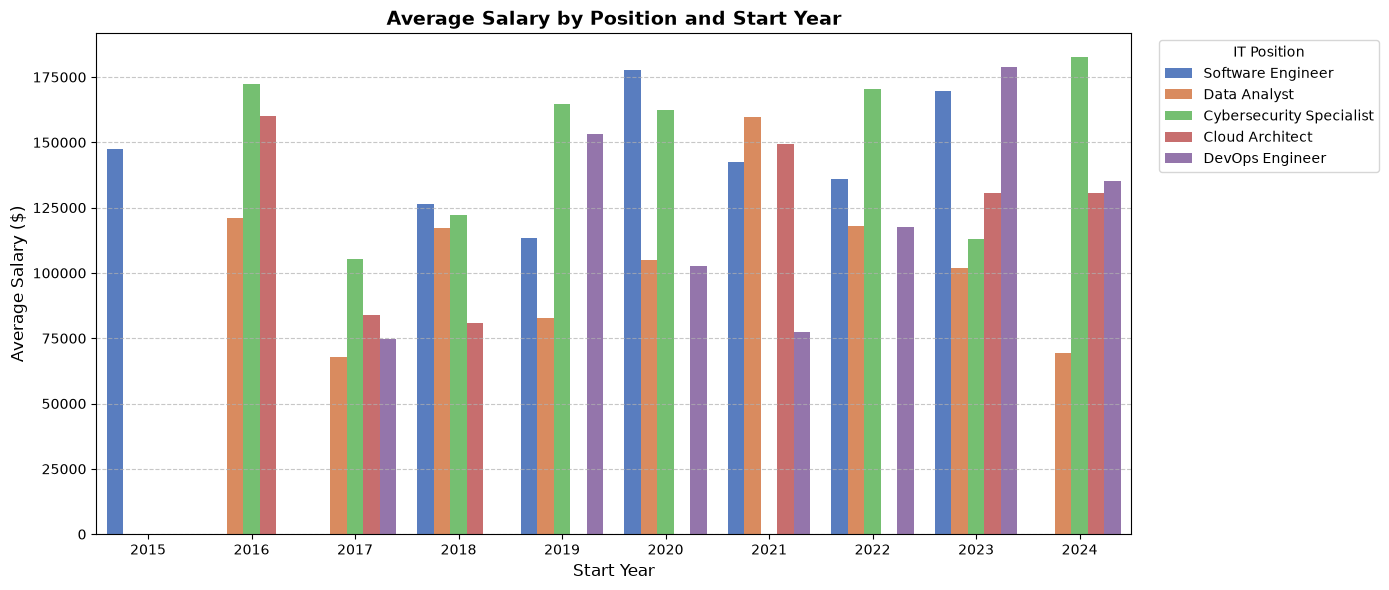

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Calculate average salary by position and start year
sns.barplot(
    data=df, 
    x='start_year', 
    y='salary', 
    hue='position', 
    errorbar=None, 
    palette='muted'
)

plt.title("Average Salary by Position and Start Year", fontsize=14, weight='bold')
plt.xlabel("Start Year", fontsize=12)
plt.ylabel("Average Salary ($)", fontsize=12)
plt.legend(title="IT Position", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualization 1 Findings
- **Cohort Variation:** Yearly hiring cohorts show salary variance across technical positions, reflecting market demand shifts between infrastructure, data, and security roles.
- **Role Parity:** Roles such as Cloud Architect and DevOps Engineer command higher entry compensation bands compared to junior analyst positions within given hiring cycles.

## 6. Advanced Visualization Challenge: Joined Dataset & Heatmap

Successfully merged Employee data with Department metadata!


,employee_id,position,department,office_location,salary
0,1,Data Analyst,Data & AI,Toronto,66556
1,2,DevOps Engineer,Cloud Infrastructure,Toronto,124196
2,3,Software Engineer,Software Engineering,Waterloo,96579
3,4,Data Analyst,Data & AI,Toronto,82790
4,5,Cybersecurity Specialist,Information Security,Waterloo,170604


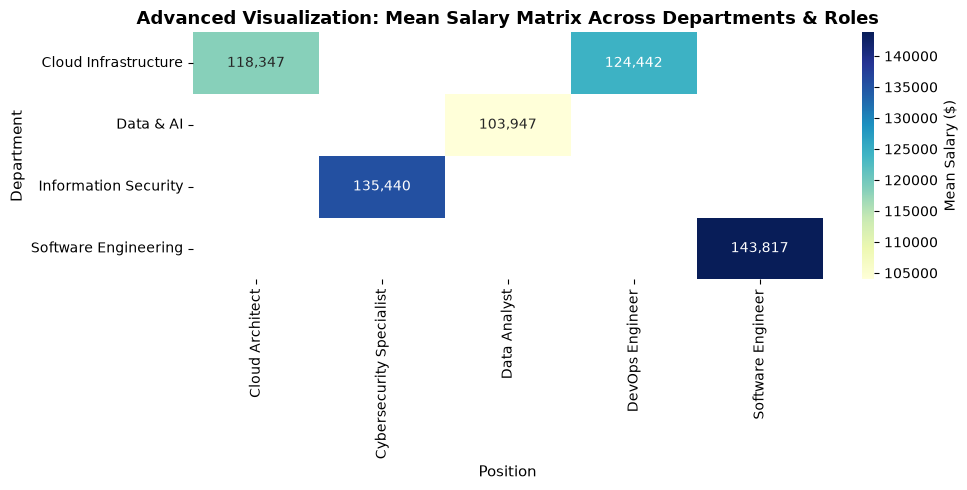

In [7]:
# Create a second table: Departments metadata
departments_data = pd.DataFrame({
    'position': [
        'Data Analyst', 
        'Software Engineer', 
        'DevOps Engineer', 
        'Cloud Architect', 
        'Cybersecurity Specialist'
    ],
    'department': [
        'Data & AI', 
        'Software Engineering', 
        'Cloud Infrastructure', 
        'Cloud Infrastructure', 
        'Information Security'
    ],
    'office_location': ['Toronto', 'Waterloo', 'Toronto', 'Ottawa', 'Waterloo'],
    'dept_budget_millions': [4.5, 8.0, 6.2, 6.2, 3.8]
})

# Perform SQL-style INNER JOIN on 'position'
merged_df = pd.merge(df, departments_data, on='position', how='inner')
print("Successfully merged Employee data with Department metadata!")
display(merged_df[['employee_id', 'position', 'department', 'office_location', 'salary']].head())

# Create a Pivot Table: Average Salary by Department and Position
pivot_salary = merged_df.pivot_table(
    values='salary', 
    index='department', 
    columns='position', 
    aggfunc='mean'
)

# Plot Advanced Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_salary, 
    annot=True, 
    fmt=",.0f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'Mean Salary ($)'}
)

plt.title("Advanced Visualization: Mean Salary Matrix Across Departments & Roles", fontsize=13, weight='bold')
plt.xlabel("Position", fontsize=11)
plt.ylabel("Department", fontsize=11)
plt.tight_layout()
plt.show()

### Advanced Visualization Findings
- **Departmental Concentration:** By joining departmental metadata, we observe organizational clustering—Cloud Infrastructure encompasses both Cloud Architects and DevOps Engineers, while Data & AI hosts analytical talent.
- **Cross-Functional Salary Distribution:** The heatmap reveals salary ceilings across operational units, enabling HR and engineering leadership to benchmark compensation parity across departments and physical office locations.

## 7. Insights & Conclusions
1. **Cloud SQL Integration:** Successfully established an automated data engineering pipeline linking Neon PostgreSQL to local Pandas analytical workflows.
2. **Data Integrity & Scaling:** Null verification confirmed complete data fidelity, while Min-Max normalization prepared raw compensation figures for algorithmic modeling.
3. **Operational Value:** Relational joining between employee telemetry and business organizational units provides clear visibility into compensation distribution, departmental allocations, and multi-year hiring dynamics.